In [1]:
RANDOM_STATE = 42

def set_seeds(seed: int = 42):
    import random
    import numpy as np

    random.seed(seed)
    np.random.seed(seed)

set_seeds(RANDOM_STATE)

In [4]:
#  Load Dataset

import pandas as pd

DATA_PATH = "/content/plastering_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")


Dataset loaded successfully


In [5]:
#  Detect Target Column

possible_targets = ["Duration_Days", "Duration_days", "duration_days", "duration"]
TARGET_COL = next((col for col in possible_targets if col in df.columns), None)

if TARGET_COL is None:
    raise ValueError(
        f"Target column not found. Checked: {possible_targets}\nAvailable columns: {df.columns.tolist()}"
    )

print(" Target Column:", TARGET_COL)

 Target Column: duration_days


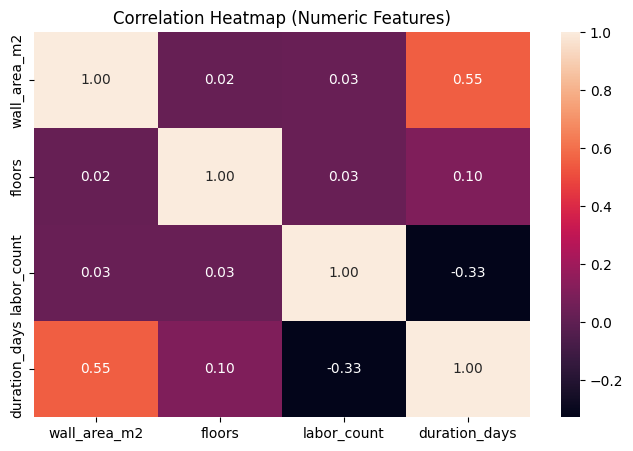

In [6]:
#  Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [8]:
#  Preprocessing Functions

def split_features_target(df, target_col):
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    return X, y

def build_preprocessor(X, scale_numeric=False):
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return preprocessor

In [9]:
#  Define Features and Target

X, y = split_features_target(df, TARGET_COL)

In [10]:
#  Train/Test Split

from sklearn.model_selection import train_test_split

TEST_SIZE = 0.20
TRAIN_SIZE = 1 - TEST_SIZE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f" Train Percentage: {TRAIN_SIZE * 100:.0f}%")
print(f" Test Percentage : {TEST_SIZE * 100:.0f}%")

 Train Percentage: 80%
 Test Percentage : 20%


In [12]:
# Model Training Functions

# Linear Regression

def train_linear_regression(X_train, y_train):
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LinearRegression

    preprocessor = build_preprocessor(X_train, scale_numeric=True)

    model = LinearRegression()

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [13]:
# Random Forest Regressor

def train_random_forest(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [14]:
# XGBoost

def train_xgboost(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from xgboost import XGBRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)

    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [15]:
# Train Models

lr_model = train_linear_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train, random_state=RANDOM_STATE)
xgb_model = train_xgboost(X_train, y_train, random_state=RANDOM_STATE)

In [16]:
# Evaluation Functions

import numpy as np

def regression_accuracy_with_tolerance(y_true, y_pred, tolerance=0.10):
    """
    Accuracy = percentage of predictions within ±10% of actual values
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = np.where(y_true == 0, 1.0, y_true)
    relative_error = np.abs(y_pred - y_true) / np.abs(denominator)

    return float(np.mean(relative_error <= tolerance))

def evaluate_model(model_name, model, X_test, y_test):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    accuracy = regression_accuracy_with_tolerance(y_test, y_pred, tolerance=0.10)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy_±10%": accuracy
    }

In [17]:
#  Evaluate All Models

import pandas as pd

results = []
results.append(evaluate_model("Linear Regression", lr_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values(by="MAE", ascending=True)

display(results_df)

,Model,MAE,RMSE,R2,Accuracy_±10%
2,XGBoost,2.479700,14.048908,0.954131,0.600000
1,Random Forest,3.214672,17.851968,0.925936,0.581667
0,Linear Regression,23.176330,50.860260,0.398835,0.028333


In [18]:
# 12) Select Best Model


best_row = results_df.iloc[0]
best_model_name = best_row["Model"]

best_model = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}[best_model_name]

print(" Best Model:", best_model_name)
print("MAE:", best_row["MAE"])
print("RMSE:", best_row["RMSE"])
print("R²:", best_row["R2"])
print("Accuracy:", best_row["Accuracy_±10%"])

 Best Model: XGBoost
MAE: 2.4797003269195557
RMSE: 14.048907819225164
R²: 0.9541307091712952
Accuracy: 0.6


In [20]:
import joblib

joblib.dump(best_model, "plastering_pipeline.pkl")

['plastering_pipeline.pkl']